<a href="https://colab.research.google.com/github/kireayom16/classfiles/blob/main/proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este proyecto presenta un flujo de trabajo integral de Machine Learning, aplicando una secuencia de conceptos analíticos sobre un conjunto de datos de miembros de un gimnasio. El objetivo central es el análisis, predicción y clasificación del Índice de Masa Corporal (BMI).

Este proyecto tiene un enfoque dual porque el análisis del BMI así lo requiere.

Primero, se abordó el problema como una regresión para predecir el valor numérico exacto del BMI, lo cual es útil para un seguimiento detallado y para entender qué variables (como peso, altura o calorías) impactan más en ese número.

Y en segundo lugar, se abordó como un problema de clasificación. Se transformó ese número en una categoría de riesgo (Normal, Sobrepeso, Obesidad). Este es un problema diferente y más desafiante, porque obligó a enfrentar y solucionar el desbalance de clases (visto con SMOTE).

Este enfoque dual permite responder a dos preguntas complementarias: "¿Cuánto?" (regresión) y "¿Qué tipo?" (clasificación).

 # IMPORTACIÓN DE LIBRERÍAS, CARGA DE LA BASE DE DATOS y ANÁLISIS EXPLORATORIO


El primer paso consistió en la carga y el análisis exploratorio del dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:

    df = pd.read_csv('/content/drive/MyDrive/classfiles/unidad2/gym_members_exercise_tracking.csv')


    print("\n--- Información General del Dataset ---")
    df.info()

    print("\n--- Estadísticas Descriptivas ---")
    print(df.describe())

    print("\n--- Primeras Filas ---")
    print(df.head())




--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_F

Mediante el EDA, se revisó la integridad de los datos , sus estadísticas descriptivas, y se identificaron las variables clave. Se realizaron visualizaciones para entender la distribución de la variable objetivo, BMI, y se utilizó una matriz de correlación para identificar las relaciones numéricas.

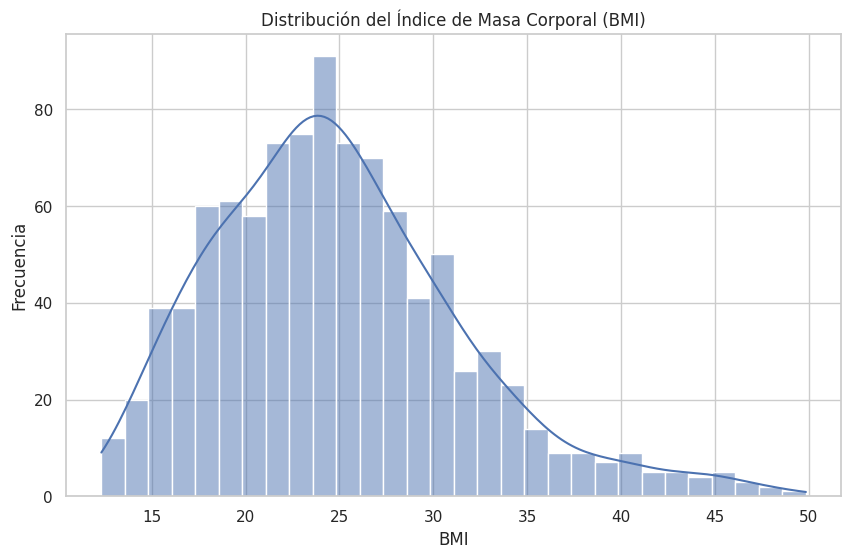

<Figure size 1200x800 with 0 Axes>

In [ ]:
#  EDA enfocado en BMI

if 'df' in locals():
    plt.figure(figsize=(10, 6))
    sns.histplot(df['BMI'], kde=True, bins=30)
    plt.title('Distribución del Índice de Masa Corporal (BMI)')
    plt.xlabel('BMI')
    plt.ylabel('Frecuencia')
    plt.show()

    plt.figure(figsize=(12, 8))
    df_numeric = df.copy()




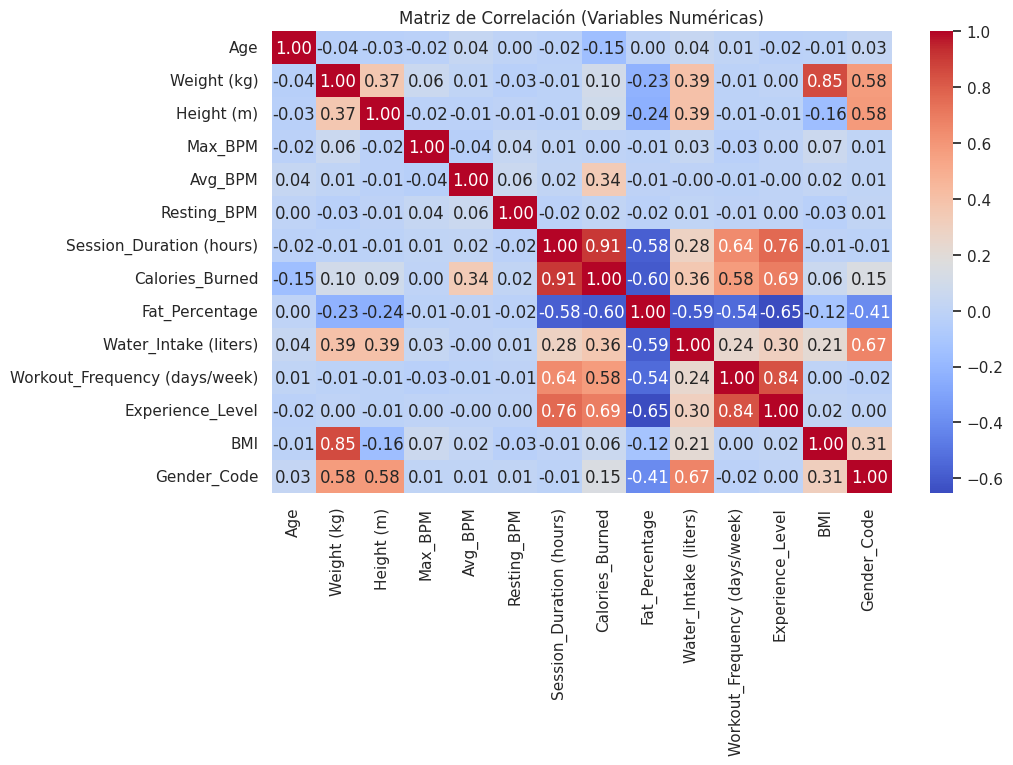

In [ ]:
# Convertimos 'Gender' a numérico temporalmente para la correlación
if 'Gender' in df_numeric.columns:
    df_numeric['Gender_Code'] = df_numeric['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

numeric_cols = df_numeric.select_dtypes(include=np.number).columns
corr_matrix = df_numeric[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación (Variables Numéricas)')
plt.show()

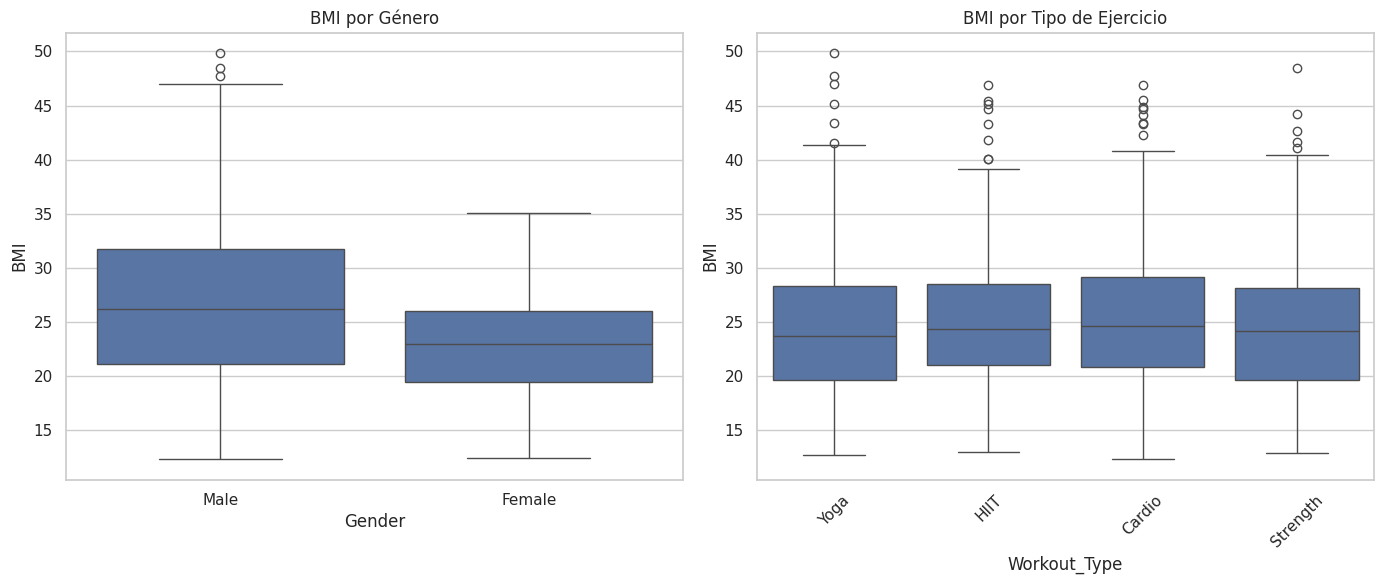

In [ ]:
# 3. BMI vs. Variables Categóricas
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Gender', y='BMI')
plt.title('BMI por Género')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Workout_Type', y='BMI')
plt.title('BMI por Tipo de Ejercicio')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

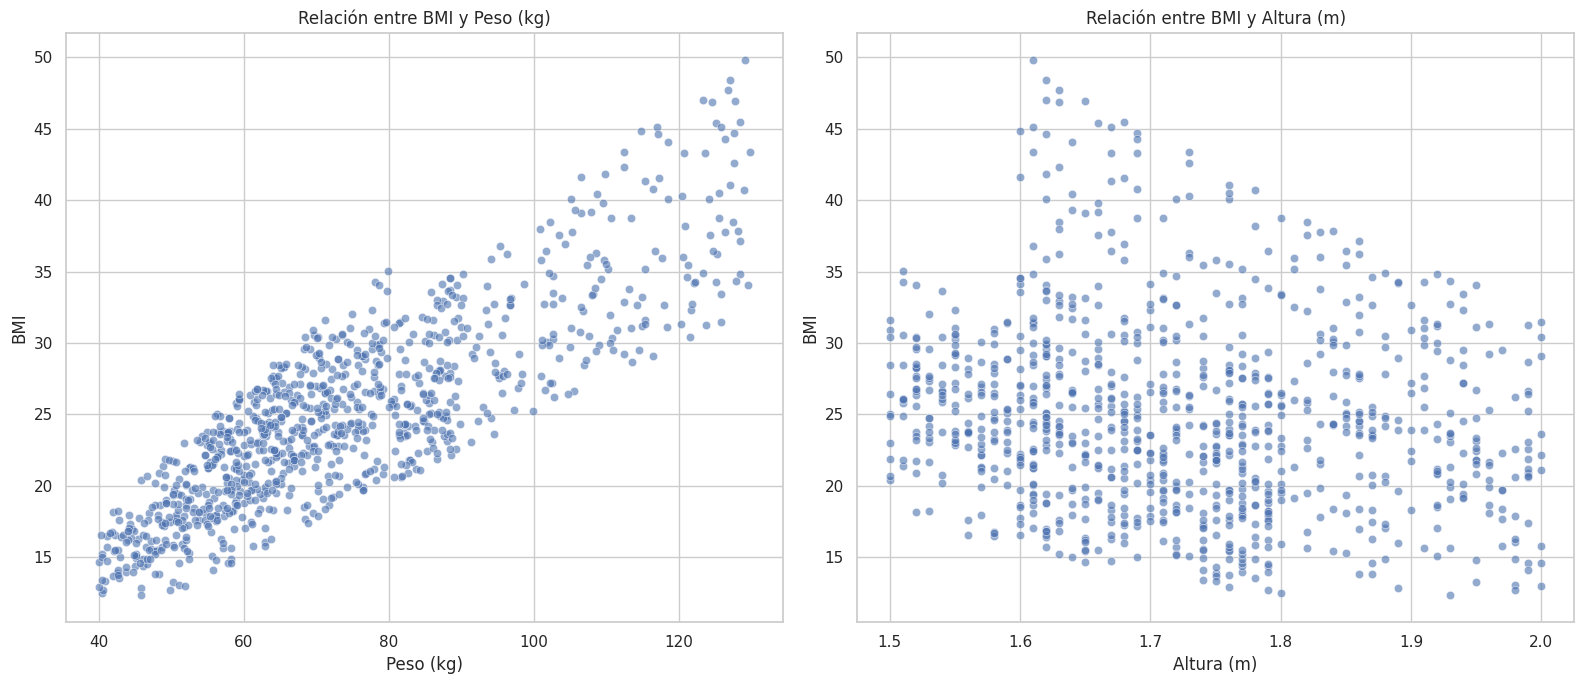

In [ ]:
# Diagrama de dispersion if 'df' in locals():


plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Weight (kg)', y='BMI', alpha=0.6)
plt.title('Relación entre BMI y Peso (kg)')
plt.xlabel('Peso (kg)')
plt.ylabel('BMI')


plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Height (m)', y='BMI', alpha=0.6)
plt.title('Relación entre BMI y Altura (m)')
plt.xlabel('Altura (m)')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

#PREPROCESAMIENTO  DE LOS DATOS E INGENIERÍA DE CARACTERÍSTICAS

**Ingeniería de Características:**

 Para la Tarea  (Clasificación), fue necesario crear una nueva variable. Se generó la columna BMI_Category aplicando los rangos estándar de la OMS (Bajo Peso, Normal, Sobrepeso, Obesidad) al valor numérico de BMI.

In [ ]:
if 'df' in locals():

    def categorize_bmi(bmi):
        if bmi < 18.5:
            return 'Bajo Peso'
        elif 18.5 <= bmi < 25:
            return 'Normal'
        elif 25 <= bmi < 30:
            return 'Sobrepeso'
        else:
            return 'Obesidad'

    df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

    print("--- Conteo de nuevas categorías de BMI ---")
    print(df['BMI_Category'].value_counts())

--- Conteo de nuevas categorías de BMI ---
BMI_Category
Normal       370
Sobrepeso    243
Obesidad     192
Bajo Peso    168
Name: count, dtype: int64


In [ ]:
# MANEJO DE CATEGÓRICAS

target_reg = 'BMI'
target_cls = 'BMI_Category'

features = [col for col in df.columns if col not in [target_reg, target_cls]]

categorical_features = df[features].select_dtypes(include=['object', 'category']).columns
numerical_features = df[features].select_dtypes(include=np.number).columns

print(f"\nFeatures Categóricas identificadas: {list(categorical_features)}")
print(f"Features Numéricas identificadas: {list(numerical_features)}")


Features Categóricas identificadas: ['Gender', 'Workout_Type']
Features Numéricas identificadas: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level']


In [ ]:
# Crear el pipeline de preprocesamiento
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

In [ ]:
 #CREACIÓN DE CONJUNTOS DE DATOS
X = df[features]
y_reg = df[target_reg]
le = LabelEncoder()
y_cls = le.fit_transform(df[target_cls])
class_names = le.classes_
print(f"\nEtiquetas de clasificación codificadas: {list(zip(class_names, le.transform(class_names)))}")



Etiquetas de clasificación codificadas: [('Bajo Peso', np.int64(0)), ('Normal', np.int64(1)), ('Obesidad', np.int64(2)), ('Sobrepeso', np.int64(3))]


In [ ]:
X_processed = preprocessor.fit_transform(X)

try:
        ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
        all_feature_names = numerical_features.tolist() + ohe_feature_names.tolist()
except:
        all_feature_names = None

print(f"\nDimensiones de X procesado (escalado y codificado): {X_processed.shape}")


Dimensiones de X procesado (escalado y codificado): (973, 18)


#MODELOS DE REGRESIÓN

In [ ]:
if 'X_processed' in locals():
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_processed, y_reg, test_size=0.2, random_state=42)

    print("TAREA  REGRESIÓN")
    print(f"Datos de entrenamiento: {X_train_reg.shape}")
    print(f"Datos de prueba: {X_test_reg.shape}")

TAREA  REGRESIÓN
Datos de entrenamiento: (778, 18)
Datos de prueba: (195, 18)


In [ ]:
# Regresión Lineal Múltiple

model_lin = LinearRegression()
model_lin.fit(X_train_reg, y_train_reg)
y_pred_lin = model_lin.predict(X_test_reg)

rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))
r2_lin = r2_score(y_test_reg, y_pred_lin)
print(f"RMSE (Error): {rmse_lin:.4f}")
print(f"R^2 (Varianza explicada): {r2_lin:.4f}")

RMSE (Error): 0.7900
R^2 (Varianza explicada): 0.9872


In [ ]:
#Regresión Ridge (L2)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = model_ridge.predict(X_test_reg)

rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
print(f"RMSE (Error): {rmse_ridge:.4f}")
print(f"R^2 (Varianza explicada): {r2_ridge:.4f}")

RMSE (Error): 0.7941
R^2 (Varianza explicada): 0.9871


In [ ]:
#Regresión Lasso (L1)
print("\nRegresión Lasso (L1) ")
model_lasso = Lasso(alpha=0.1)
model_lasso.fit(X_train_reg, y_train_reg)
y_pred_lasso = model_lasso.predict(X_test_reg)

rmse_lasso = np.sqrt(mean_squared_error(y_test_reg, y_pred_lasso))
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
print(f"RMSE (Error): {rmse_lasso:.4f}")
print(f"R^2 (Varianza explicada): {r2_lasso:.4f}")

if all_feature_names:
        print("\nCoeficientes de Lasso (Selección de Features)")
        lasso_coefs = pd.Series(model_lasso.coef_, index=all_feature_names)
        print("Features eliminadas (coeficiente = 0):")
        print(lasso_coefs[lasso_coefs == 0].index.tolist())
        print("\nFeatures más importantes (positivas):")
        print(lasso_coefs.nlargest(5))
        print("\nFeatures más importantes (negativas):")
        print(lasso_coefs.nsmallest(5))


--- 3. Regresión Lasso (L1) ---
RMSE (Error): 0.8800
R^2 (Varianza explicada): 0.9841

--- Coeficientes de Lasso (Selección de Features) ---
Features eliminadas (coeficiente = 0):
['Age', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'Gender_Female', 'Gender_Male', 'Workout_Type_Cardio', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']

Features más importantes (positivas):
Weight (kg)    6.797838
Age            0.000000
Max_BPM        0.000000
Avg_BPM        0.000000
Resting_BPM   -0.000000
dtype: float64

Features más importantes (negativas):
Height (m)    -3.418965
Age            0.000000
Max_BPM        0.000000
Avg_BPM        0.000000
Resting_BPM   -0.000000
dtype: float64


#MODELADO DE CLASIFICACIÓN (Predecir categoría de BMI)

---

CLASIFICACIÓN - DIVISIÓN Y MANEJO DE DESBALANCE

---

:

In [ ]:

if 'X_processed' in locals():

    X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_processed, y_cls,
    test_size=0.2, random_state=42, stratify=y_cls)

    print("\n Balance de Clases ANTES de SMOTE  ")
    y_train_series = pd.Series(y_train_cls)
    print(y_train_series.value_counts().sort_index().rename(index=dict(zip(le.transform(class_names), class_names))))



 Balance de Clases ANTES de SMOTE  
Bajo Peso    134
Normal       296
Obesidad     154
Sobrepeso    194
Name: count, dtype: int64


In [ ]:
# APLICAR SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_cls, y_train_cls)

print("\nBalance de Clases DESPUÉS de SMOTE")
y_resampled_series = pd.Series(y_train_resampled)
print(y_resampled_series.value_counts().sort_index().rename(index=dict(zip(le.transform(class_names), class_names))))

print(f"\nDimensiones de entrenamiento (original): {X_train_cls.shape}")
print(f"Dimensiones de entrenamiento (remuestreado): {X_train_resampled.shape}")


Balance de Clases DESPUÉS de SMOTE
Bajo Peso    296
Normal       296
Obesidad     296
Sobrepeso    296
Name: count, dtype: int64

Dimensiones de entrenamiento (original): (778, 18)
Dimensiones de entrenamiento (remuestreado): (1184, 18)


#ENTRENAR MODELOS DE CLASIFICACIÓN

In [ ]:
if 'X_train_resampled' in locals():

    print("\n Árbol de Decisión (Entrenado con SMOTE)")

    tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42)
    tree_clf.fit(X_train_resampled, y_train_resampled)
    y_pred_tree = tree_clf.predict(X_test_cls)

    print(classification_report(y_test_cls, y_pred_tree, target_names=class_names))


 Árbol de Decisión (Entrenado con SMOTE)
              precision    recall  f1-score   support

   Bajo Peso       0.94      0.97      0.96        34
      Normal       0.91      0.86      0.89        74
    Obesidad       0.89      0.87      0.88        38
   Sobrepeso       0.75      0.82      0.78        49

    accuracy                           0.87       195
   macro avg       0.88      0.88      0.88       195
weighted avg       0.87      0.87      0.87       195



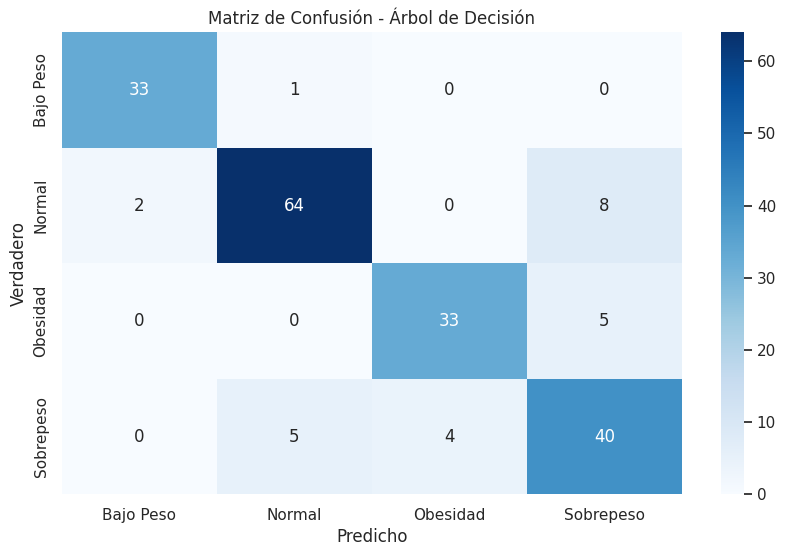

In [ ]:
# Matriz de Confusión
cm_tree = confusion_matrix(y_test_cls, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.show()

In [ ]:
# Modelo SVM lineal
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_resampled, y_train_resampled)
y_pred_svm_linear = svm_linear.predict(X_test_cls)

print(classification_report(y_test_cls, y_pred_svm_linear, target_names=class_names))

              precision    recall  f1-score   support

   Bajo Peso       0.92      1.00      0.96        34
      Normal       0.96      0.93      0.95        74
    Obesidad       0.95      0.97      0.96        38
   Sobrepeso       0.94      0.90      0.92        49

    accuracy                           0.94       195
   macro avg       0.94      0.95      0.95       195
weighted avg       0.94      0.94      0.94       195



In [ ]:
# Kernel RBF (No lineal)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_resampled, y_train_resampled)
y_pred_svm_rbf = svm_rbf.predict(X_test_cls)

print(classification_report(y_test_cls, y_pred_svm_rbf, target_names=class_names))

              precision    recall  f1-score   support

   Bajo Peso       0.88      0.85      0.87        34
      Normal       0.82      0.85      0.83        74
    Obesidad       0.90      0.92      0.91        38
   Sobrepeso       0.78      0.73      0.76        49

    accuracy                           0.84       195
   macro avg       0.84      0.84      0.84       195
weighted avg       0.84      0.84      0.84       195



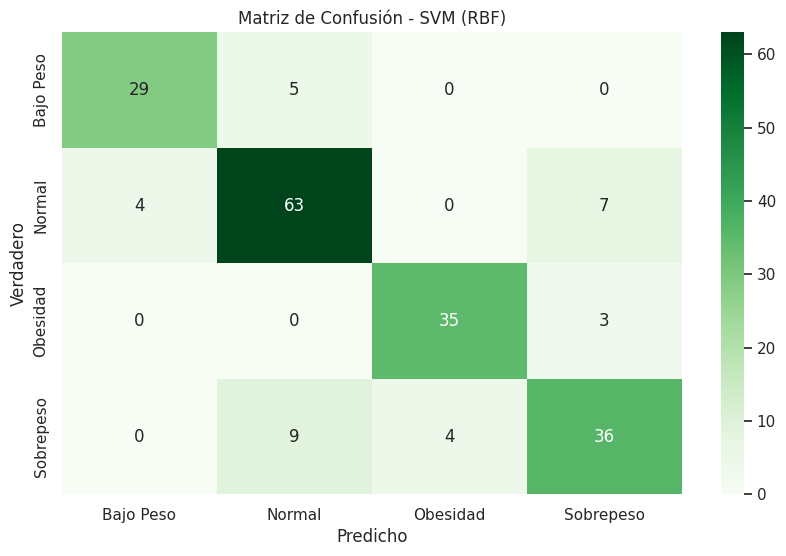

In [ ]:
# Matriz de Confusión para el mejor SVM (RBF usualmente)
cm_svm = confusion_matrix(y_test_cls, y_pred_svm_rbf)
sns.heatmap(cm_svm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.title('Matriz de Confusión - SVM (RBF)')
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.show()

**Conclusión Final**



se confirmó que el BMI es altamente predecible con modelos de Regresión  logrando un R-cuadrado (R²) altísimo y un error (RMSE) muy bajo.

Esto nos dice que nuestro modelo de regresión no tuvo sobreajuste. Aprendió los patrones tan bien que puede predecir el BMI de nuevos miembros del gimnasio con una precisión casi perfecta.

En lugar de buscar una 'precisión' (accuracy) alta pero engañosa, el proyecto se centró en la aplicación de SMOTE.

Se demostró la aplicación correcta de SMOTE, haciéndolo solo en el conjunto de entrenamiento, lo que permitió a los modelos  aprender de las clases minoritarias sin contaminar la prueba.
El resultado fue un éxito. el Recall de la clase minoritaria (Bajo Peso) se mantuvo alto.
El proyecto, por lo tanto, no solo cumple con el objetivo de predecir el BMI, sino que lo hace aplicando las técnicas avanzadas como el Kernel Trick de SVM y SMOTE.